In [11]:
import sys
import json

import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import pandas as pd

from astropy import units as u
from astropy.io import fits
from astropy.cosmology import LambdaCDM, Planck18

sys.path.insert(0, '..')
from config.settings import DATA_DIR, CATALOG_DIR

In [12]:
catalog_data = json.load(open(DATA_DIR / "catalog_info.json"))
catalog_name = "Biteau2021"

catalog_info = catalog_data[catalog_name]
catalog_path = CATALOG_DIR / catalog_info["file_path"]
catalog_header = catalog_info["header"]

In [13]:
import io
import pandas as pd

# Define the byte-by-byte schema
schema = [
    (1, 29, "Name"),
    (31, 37, "RAJ2000"),
    (39, 45, "DEJ2000"),
    (47, 53, "GLON"),
    (55, 61, "GLAT"),
    (63, 63, "flag_asso"),
    (65, 72, "distL"),
    (74, 74, "r_distL"),
    (76, 80, "Mstar"),
    (82, 82, "r_Mstar"),
    (84, 88, "cNm"),
    (90, 94, "SFR"),
    (96, 96, "r_SFR"),
    (98, 102, "cNs"),
    (104, 110, "PGC"),
    (112, 130, "AllWISE"),
    (132, 138, "IDX"),
]

# Convert to pandas colspecs: (0-based start, 0-based end exclusive)
colspecs = [(start - 1, end) for start, end, _ in schema]
names = [name for _, _, name in schema]


def read_catalog(file_path):
    """Skips the MRT header dynamically and parses the data rows into a DataFrame."""
    data_lines = []
    header_ended = False
    dash_count = 0

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            # Count the divider rows to find where data starts
            if line.startswith("------------------------------------------------"):
                dash_count += 1
                # The 4th line of dashes typically marks the absolute end of the metadata header
                if dash_count == 4:
                    header_ended = True
                continue

            # Start collecting rows only after the header block has closed
            if header_ended and line.strip():
                data_lines.append(line)

    # Join the filtered data lines back together for pandas fixed-width reader
    data_buffer = io.StringIO("".join(data_lines))

    df = pd.read_fwf(
        data_buffer, colspecs=colspecs, names=names, header=None
    )

    # Clean up whitespace from string columns
    df["Name"] = df["Name"].str.strip()
    if "AllWISE" in df.columns:
        df["AllWISE"] = df["AllWISE"].str.strip()

    return df

In [14]:
galaxies = read_catalog(catalog_path)
galaxies.head()

,Name,RAJ2000,DEJ2000,GLON,GLAT,flag_asso,distL,r_distL,Mstar,r_Mstar,cNm,SFR,r_SFR,cNs,PGC,AllWISE,IDX
0,NGC0253,11.893,-25.292,97.435,-87.970,1,3.70,4,10.76,0,0.997,0.26,0,0.913,2789.0,J004733.14-251717.7,0.0
1,NGC5128,201.370,-43.017,309.520,19.419,1,3.68,4,10.67,0,0.997,-0.06,0,0.913,46957.0,J132527.62-430109.1,1.0
2,NGC5236,204.250,-29.868,314.580,31.971,1,4.90,4,10.64,0,0.996,0.44,0,0.903,48082.0,J133700.61-295155.5,3.0
3,NGC4736,192.723,41.119,123.357,76.008,1,4.41,4,10.34,0,0.996,-0.43,0,0.907,43495.0,J125053.14+410712.7,4.0
4,NGC0055,3.785,-39.220,332.667,-75.739,1,2.11,4,9.26,0,0.998,-0.36,0,0.930,1014.0,J001453.92-391156.4,5.0


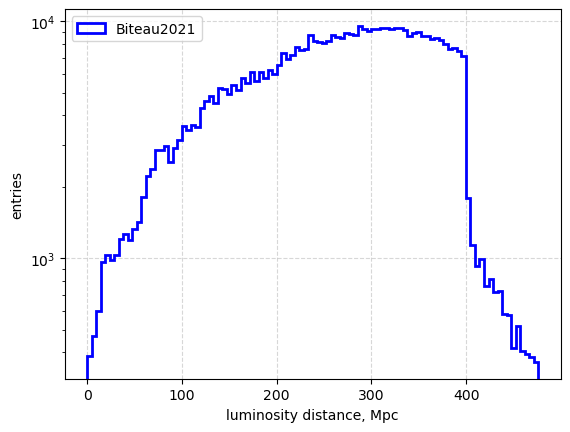

In [15]:
# z_bins = np.linspace(0, 0.4, 100)

plt.hist(galaxies['distL'], bins=100, range=[0, Planck18.luminosity_distance(0.1).to_value(u.Mpc)], histtype='step', label='Biteau2021', color='blue', linewidth=2)

# plt.xscale('log')
plt.xlabel('luminosity distance, Mpc')

plt.yscale('log')
plt.ylabel('entries')

plt.grid(linestyle='--', alpha=0.5)
plt.legend(loc=2)

plt.show()

(array([50322., 45600., 49321., 48991., 57131., 49091., 52809., 54243.,
        51183., 51381.]),
 array([  0.,  36.,  72., 108., 144., 180., 216., 252., 288., 324., 360.]),
 <BarContainer object of 10 artists>)

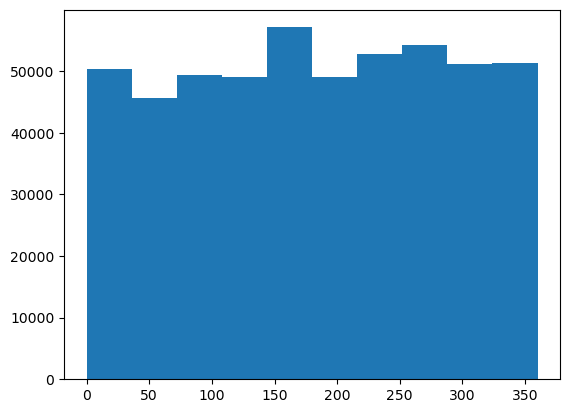

In [16]:
plt.hist(galaxies['GLON'])

In [17]:
galaxies = galaxies[galaxies['distL'] <= 400]  # Filter galaxies within 400 Mpc

In [18]:
glon_corrected = galaxies['GLON'] - 360 * (galaxies['GLON'] > 180)  # Correct GLON to be in the range [-180, 180]

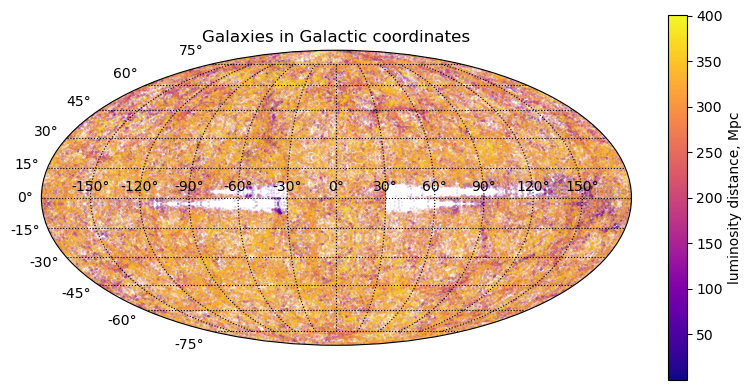

In [19]:
sparce = 1

plt.figure(figsize=(8, 4))
plt.subplot(projection="mollweide")
plt.scatter(
    np.deg2rad(glon_corrected[::sparce]),
    np.deg2rad(galaxies["GLAT"][::sparce]),
    c=galaxies["distL"][::sparce],
    s=0.005,
    cmap="plasma",
)
plt.colorbar(label="luminosity distance, Mpc")
plt.title("Galaxies in Galactic coordinates")
plt.grid(color='black', linestyle=':')
plt.tight_layout()
plt.show()

## Healpix part

In [86]:
# bin_edges = np.linspace(0, 400, 21)
bin_edges = np.array([0, 40, 170, 295, 418])
bins = [(bin_edges[i], bin_edges[i+1]) for i in range(len(bin_edges)-1)]
bins

[(0, 40), (40, 170), (170, 295), (295, 418)]

In [87]:
z = galaxies['distL'].values

### Plot overdensity

In [88]:
nside = 64
npix = hp.nside2npix(nside)
print(npix)

data_bins = []

for i in range(len(bins)):
    # data
    good_i = (z > bins[i][0]) * (z <= bins[i][1])
    pix_i = hp.ang2pix(nside, galaxies["RAJ2000"][good_i], galaxies["DEJ2000"][good_i], lonlat=True)
    map_i = np.bincount(pix_i, minlength=npix)
    data_bins.append(map_i)

49152


In [89]:
ra_pix, dec_pix = hp.pix2ang(nside, np.arange(npix), lonlat=True)

from astropy.coordinates import SkyCoord
coords = SkyCoord(ra=ra_pix * u.deg, dec=dec_pix * u.deg, frame='icrs')

glat = coords.galactic.b.deg

mask = np.abs(glat) >= 10  # Mask out pixels with absolute latitude less than 10 degrees

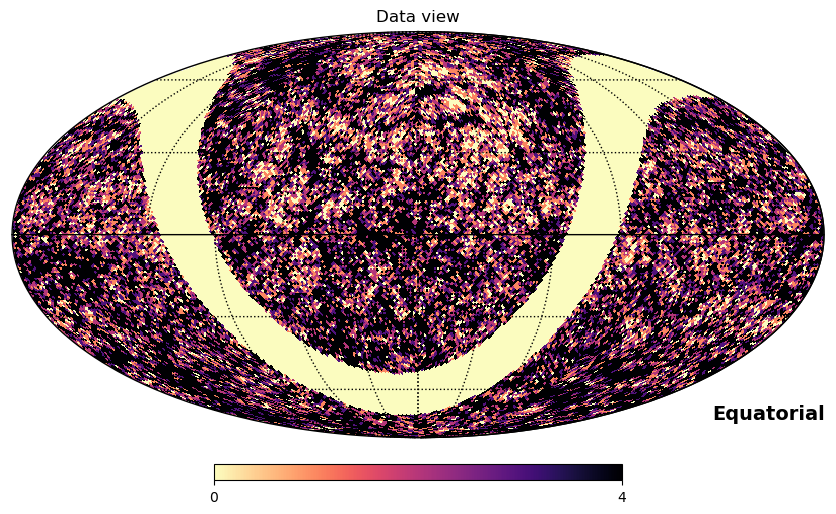

In [90]:
hp.mollview(data_bins[-1] * mask, title="Data view", rot=(180, 0, 0), coord='C', max=4, cmap='magma_r')
hp.graticule()

In [99]:
# OVERDENSITY FUNCTION

delta_bins = []
delta_bins_s = []

for i in range(len(bins)):
    # normalization coefficient (data / sampling)
    delta_i = np.zeros(npix, dtype=float)
    delta_s = np.zeros(npix, dtype=float)
       
    z_avg = np.average(bins[i])  # Calculate the average luminosity distance for non-zero pixels
    smoothing = 5 * np.sqrt(2) / z_avg
    sm_deg = np.rad2deg(smoothing)
    print(f"{z_avg:.3f} <-> {sm_deg:.2f}")
    
    data_bins_s = np.clip(hp.smoothing(data_bins[i], sigma=smoothing), a_min=0.0, a_max=1e8)
    
    avg_i = np.mean(data_bins_s[mask])  # Calculate the average of non-zero pixels in the smoothed data map

    delta_s = (data_bins_s / avg_i - 1) * mask
    delta_bins_s.append(delta_s)

20.000 <-> 20.26
105.000 <-> 3.86
232.500 <-> 1.74
356.500 <-> 1.14


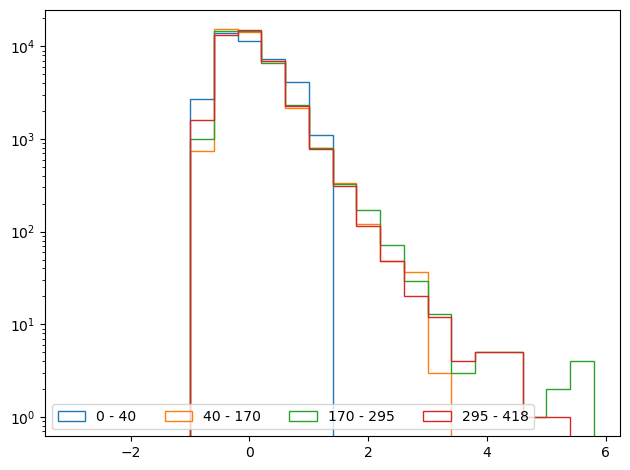

In [100]:
for i in range(len(bins)):
    plt.hist(delta_bins_s[i][mask].ravel(), bins = np.arange(-3.0, 6.1, 0.4), histtype='step', linewidth=1, label=f"{bins[i][0]:.0f} - {bins[i][1]:.0f}")
plt.yscale('log')
plt.legend(ncol=4)
plt.tight_layout()
plt.show()

In [101]:
for i in range(len(bins)):
    print(np.nanmean(delta_bins_s[i]))   # should be ~0
    print(np.nanstd(delta_bins_s[i]))    # reasonable scatter

-1.850371707708594e-17
0.4201019611615157
8.326672684688674e-17
0.3997734560000071
-4.0476881106125497e-17
0.4280276137305015
-9.25185853854297e-18
0.4129596051659527


<Figure size 640x480 with 0 Axes>

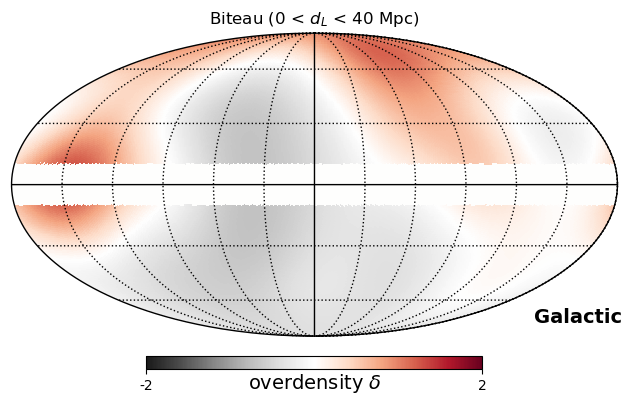

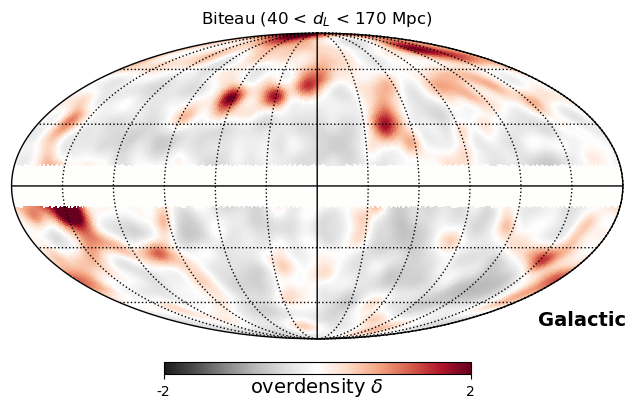

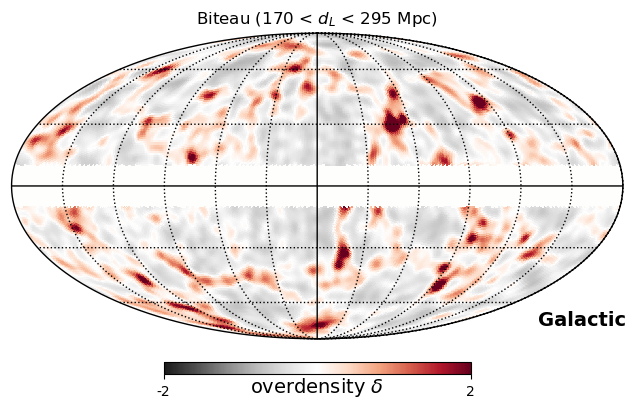

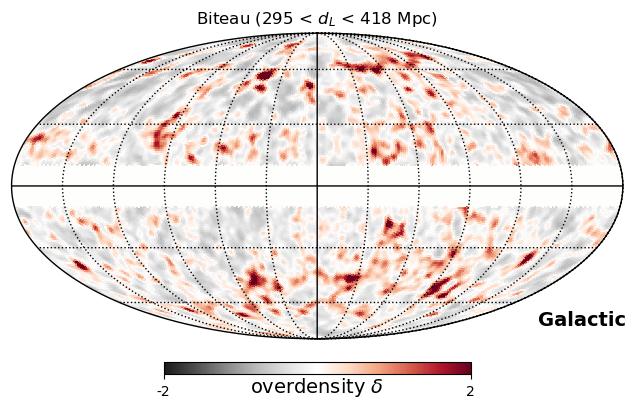

In [102]:
fig = plt.figure(figsize=(7, 4), num=1)

for i in range(len(bins)):
    plt.figure()
    hp.mollview(delta_bins_s[i], cmap='RdGy_r', min=-2, max=2, coord=['C', 'G'], title=f"Biteau ({bins[i][0]} < $d_L$ < {bins[i][1]} Mpc)",
                unit=r"overdensity $\delta$", fig=1, xsize=900)
    hp.graticule()
    plt.show()